# K-Means Clustering — From Scratch & with Scikit-Learn

**What this notebook covers:**
- The core theory behind K-Means clustering (Lloyd's algorithm, k-means++ initialization)
- Loading and preprocessing a real-world customer dataset
- A from-scratch K-Means implementation using only `numpy`
- A reference implementation using `scikit-learn`, with a direct metric comparison
- Visualizations of the resulting customer segments
- Hyperparameter experiments (number of clusters `k`, initialization method)
- An interview-style walkthrough of the most commonly asked K-Means conceptual question
- Five key takeaways to remember for placement interviews

**Prerequisites:** comfort with Python, `numpy`/`pandas` basics, Euclidean distance, and introductory statistics (mean, variance).

**Dataset:** [Mall Customer Segmentation Data — Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) — 200 mall customers with `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

**Credits:** Dataset originally curated by Kaggle user *vjchoudhary7*; it is one of the most widely used public datasets for teaching unsupervised learning / customer segmentation. Notebook authored for the Gradientts ML Intern Workflow curriculum.

In [11]:
import numpy as np                                          # numerical operations; backbone of the from-scratch algorithm
import pandas as pd                                         # loading and manipulating the tabular dataset
import matplotlib.pyplot as plt                              # core plotting library
import seaborn as sns                                        # statistical plotting on top of matplotlib

from sklearn.cluster import KMeans                            # reference, production-grade K-Means implementation
from sklearn.preprocessing import StandardScaler               # feature scaling (K-Means is distance-based)
from sklearn.metrics import silhouette_score                   # clustering quality metric used throughout

np.random.seed(42)        # CRITICAL RULE: fix the seed for any random operations -> reproducible results
sns.set_style("whitegrid")
%matplotlib inline

## Part 1: Theory Recap

- K-Means is an **unsupervised, centroid-based** clustering algorithm that partitions `n` data points into `k` clusters by minimizing within-cluster variance (inertia).
- It runs iteratively (**Lloyd's algorithm**): (1) initialize `k` centroids, (2) assign each point to its nearest centroid, (3) recompute each centroid as the mean of its assigned points, (4) repeat until assignments stop changing.
- The algorithm always **converges**, but only to a **local optimum** — this is why initialization matters, and why **k-means++** (smart, spread-out initialization) is the standard improvement over naive random initialization.
- The number of clusters `k` is a **hyperparameter** chosen before fitting, typically via the **Elbow Method** (inertia vs. `k`) or the **Silhouette Score**.
- K-Means assumes roughly **spherical, similarly-sized clusters** and is sensitive to feature scale — which is why **standardizing features is a mandatory preprocessing step**.

## Loading the Dataset

We use the **Mall Customer Segmentation Data** from Kaggle (200 records). Below we load the CSV and inspect its structure.

**Features:**
- `CustomerID` — unique identifier (dropped before modeling; not informative)
- `Gender` — customer gender (categorical)
- `Age` — customer age in years
- `Annual Income (k$)` — annual income in thousands of dollars
- `Spending Score (1-100)` — a score assigned by the mall based on customer spending behavior

**Target variable:** K-Means is **unsupervised** — there is no target/label column. Instead of predicting a value, we discover natural groupings ("segments") of customers using `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

In [12]:
df = pd.read_csv("Mall_Customers.csv")          # load the real-world Kaggle dataset (no synthetic/generated data)

print("Dataset shape:", df.shape)
print("\n--- df.head() ---")
print(df.head())
print("\n--- df.info() ---")
df.info()
print("\n--- df.describe() ---")
print(df.describe())

Dataset shape: (200, 5)

--- df.head() ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

--- df.describe

## Preprocessing

Before clustering, we: check for missing values, drop the non-informative `CustomerID`, numerically encode `Gender` (in case we inspect it later), and **standardize** the numeric features (`Age`, `Annual Income (k$)`, `Spending Score (1-100)`). Standardization matters because K-Means relies on Euclidean distance, and unscaled features (income in the hundreds vs. a 1–100 score) would otherwise dominate the clustering unfairly.

In [13]:
print("Missing values per column:")
print(df.isnull().sum())              # confirm there are no nulls to handle in this clean dataset

df_clean = df.drop(columns=["CustomerID"])                              # drop ID -> not a meaningful clustering feature
df_clean["Gender"] = df_clean["Gender"].map({"Male": 0, "Female": 1})    # encode the only categorical column

feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]   # numeric features used for clustering
X_raw = df_clean[feature_cols].values

scaler = StandardScaler()                       # K-Means uses Euclidean distance -> features must share a scale
X_scaled = scaler.fit_transform(X_raw)

print("\nScaled feature sample (first 5 rows):")
print(np.round(X_scaled[:5], 3))

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Scaled feature sample (first 5 rows):
[[-1.425 -1.739 -0.435]
 [-1.281 -1.739  1.196]
 [-1.353 -1.701 -1.716]
 [-1.138 -1.701  1.04 ]
 [-0.563 -1.663 -0.396]]


## Part 2: From-Scratch Implementation

We'll build a `KMeansScratch` class implementing **Lloyd's algorithm** using only `numpy`: a k-means++-style initializer, an **assignment step** (nearest centroid by Euclidean distance), an **update step** (recompute centroid means), and a `fit()` / `predict()` interface mirroring scikit-learn's API. Building this by hand cements exactly the mechanics interviewers probe — initialization strategy, the assign/update loop, the convergence criterion, and edge cases like empty clusters — and lets us directly benchmark our results against sklearn's optimized implementation.

In [14]:
class KMeansScratch:
    """
    K-Means clustering implemented from scratch using only numpy.
    Mirrors the scikit-learn API with fit() and predict() methods.
    """

    def __init__(self, n_clusters=5, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters          # k: number of clusters to find
        self.max_iter = max_iter              # safety cap on Lloyd's algorithm iterations
        self.tol = tol                        # convergence threshold on centroid movement
        self.random_state = random_state      # INTERVIEW NOTE: fixing this matters - K-Means is sensitive to initialization
        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0

    def _init_centroids(self, X):
        """k-means++ initialization: spreads out initial centroids to reduce the chance of a bad local optimum."""
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]
        centroids = [X[rng.randint(n_samples)]]          # first centroid: one random data point
        # INTERVIEW NOTE: each subsequent centroid is chosen with probability proportional to its squared
        # distance from the nearest *already chosen* centroid -> spreads centroids out, unlike pure random init.
        for _ in range(1, self.n_clusters):
            dist_sq = np.array([min(np.sum((x - c) ** 2) for c in centroids) for x in X])
            probs = dist_sq / dist_sq.sum()
            cumulative_probs = np.cumsum(probs)
            next_idx = np.searchsorted(cumulative_probs, rng.rand())
            centroids.append(X[next_idx])
        return np.array(centroids)

    def _assign_clusters(self, X, centroids):
        """Assign each point to its nearest centroid (Euclidean distance) -> the 'E-step' of Lloyd's algorithm."""
        # INTERVIEW NOTE: vectorized pairwise distance computation, shape (n_samples, k) - avoids Python loops
        distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
        return np.argmin(distances, axis=1), distances

    def _update_centroids(self, X, labels):
        """Recompute each centroid as the mean of points currently assigned to it -> the 'M-step'."""
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            points_in_cluster = X[labels == k]
            if len(points_in_cluster) > 0:
                new_centroids[k] = points_in_cluster.mean(axis=0)
            else:
                # INTERVIEW NOTE: empty-cluster edge case - re-seed with a random point so the loop doesn't break
                new_centroids[k] = X[np.random.RandomState(self.random_state).randint(X.shape[0])]
        return new_centroids

    def fit(self, X):
        """Run Lloyd's algorithm until centroid movement < tol, or max_iter is reached."""
        self.centroids_ = self._init_centroids(X)
        labels, distances = None, None
        for i in range(self.max_iter):
            labels, distances = self._assign_clusters(X, self.centroids_)
            new_centroids = self._update_centroids(X, labels)
            shift = np.linalg.norm(new_centroids - self.centroids_)   # INTERVIEW NOTE: convergence check
            self.centroids_ = new_centroids
            self.n_iter_ = i + 1
            if shift < self.tol:
                break
        self.labels_ = labels
        # Inertia = sum of squared distances of each point to its assigned centroid (the objective K-Means minimizes)
        self.inertia_ = float(np.sum([distances[idx, label] ** 2 for idx, label in enumerate(labels)]))
        return self

    def predict(self, X):
        """Assign new points to the nearest already-fitted centroid."""
        labels, _ = self._assign_clusters(X, self.centroids_)
        return labels

### Fitting & Evaluating the Scratch Model

We fit `KMeansScratch` with `k=5` (justified by the Elbow/Silhouette sweep in Part 4) and evaluate it with **inertia** (lower is tighter clusters) and the **silhouette score** (ranges -1 to 1; higher means better-separated, more cohesive clusters).

In [15]:
kmeans_scratch = KMeansScratch(n_clusters=5, random_state=42)
kmeans_scratch.fit(X_scaled)

scratch_labels = kmeans_scratch.labels_
scratch_inertia = kmeans_scratch.inertia_
scratch_silhouette = silhouette_score(X_scaled, scratch_labels)

print(f"Converged in {kmeans_scratch.n_iter_} iterations")
print(f"Scratch Inertia:          {scratch_inertia:.2f}")
print(f"Scratch Silhouette Score: {scratch_silhouette:.4f}")
print(f"Cluster sizes: {np.bincount(scratch_labels)}")

Converged in 6 iterations
Scratch Inertia:          168.76
Scratch Silhouette Score: 0.4104
Cluster sizes: [58 39 22 34 47]


## Part 3: Scikit-Learn Implementation

Scikit-learn's `KMeans` runs the same Lloyd's-algorithm core but adds production-grade engineering on top: an optimized k-means++ initializer, multiple random restarts (`n_init`) with the best (lowest-inertia) result kept automatically, and highly vectorized/compiled internals. It should land on a similar — often near-identical — solution to our scratch implementation, but converge faster and more reliably across runs.

In [16]:
kmeans_sklearn = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
sklearn_labels = kmeans_sklearn.fit_predict(X_scaled)

sklearn_inertia = kmeans_sklearn.inertia_
sklearn_silhouette = silhouette_score(X_scaled, sklearn_labels)

print(f"Sklearn Inertia:              {sklearn_inertia:.2f}")
print(f"Sklearn Silhouette Score:     {sklearn_silhouette:.4f}")
print(f"Sklearn iterations to converge: {kmeans_sklearn.n_iter_}")

print("\n--- Comparison: Scratch vs Sklearn ---")
comparison = pd.DataFrame({
    "Metric": ["Inertia", "Silhouette Score"],
    "From Scratch": [scratch_inertia, scratch_silhouette],
    "Scikit-Learn": [sklearn_inertia, sklearn_silhouette],
})
print(comparison.to_string(index=False))

Sklearn Inertia:              168.25
Sklearn Silhouette Score:     0.4166
Sklearn iterations to converge: 9

--- Comparison: Scratch vs Sklearn ---
          Metric  From Scratch  Scikit-Learn
         Inertia    168.761788    168.247580
Silhouette Score      0.410400      0.416643


## Visualizing the Clusters

Two plots: **(1)** the customer segments in *Annual Income vs. Spending Score* space — the most business-interpretable view — with sklearn's centroids overlaid, and **(2)** the average feature profile of each cluster, which gives each segment a human-readable "personality" (e.g. "young, high income, high spender").

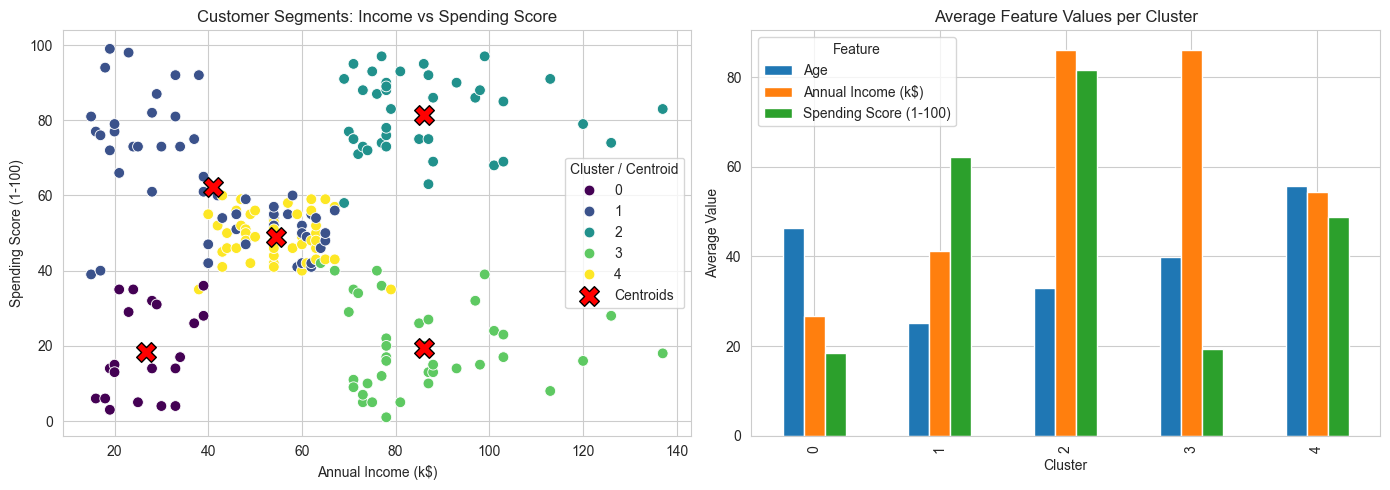

In [17]:
df_clean["Cluster"] = sklearn_labels
centroids_original_scale = scaler.inverse_transform(kmeans_sklearn.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: clusters in Income vs Spending Score space, with centroids
sns.scatterplot(
    data=df_clean, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette="viridis", s=60, ax=axes[0], legend="full"
)
axes[0].scatter(
    centroids_original_scale[:, 1], centroids_original_scale[:, 2],
    c="red", marker="X", s=200, edgecolor="black", label="Centroids"
)
axes[0].set_title("Customer Segments: Income vs Spending Score")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")
axes[0].legend(title="Cluster / Centroid")

# Plot 2: average feature profile per cluster
cluster_profile = df_clean.groupby("Cluster")[feature_cols].mean()
cluster_profile.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Feature Values per Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Average Value")
axes[1].legend(title="Feature")

plt.tight_layout()
plt.show()

## Part 4: Hyperparameter Experiments

The two hyperparameters that matter most for K-Means are **`k` (n_clusters)** — too few merges genuinely distinct segments together, too many fragments natural groups — and the **initialization method** (`init`), since K-Means solves a non-convex optimization problem that can land on different local optima depending on the starting centroids. We vary both below: an Elbow + Silhouette sweep over `k`, and a stability comparison of `random` vs. `k-means++` initialization across repeated runs.

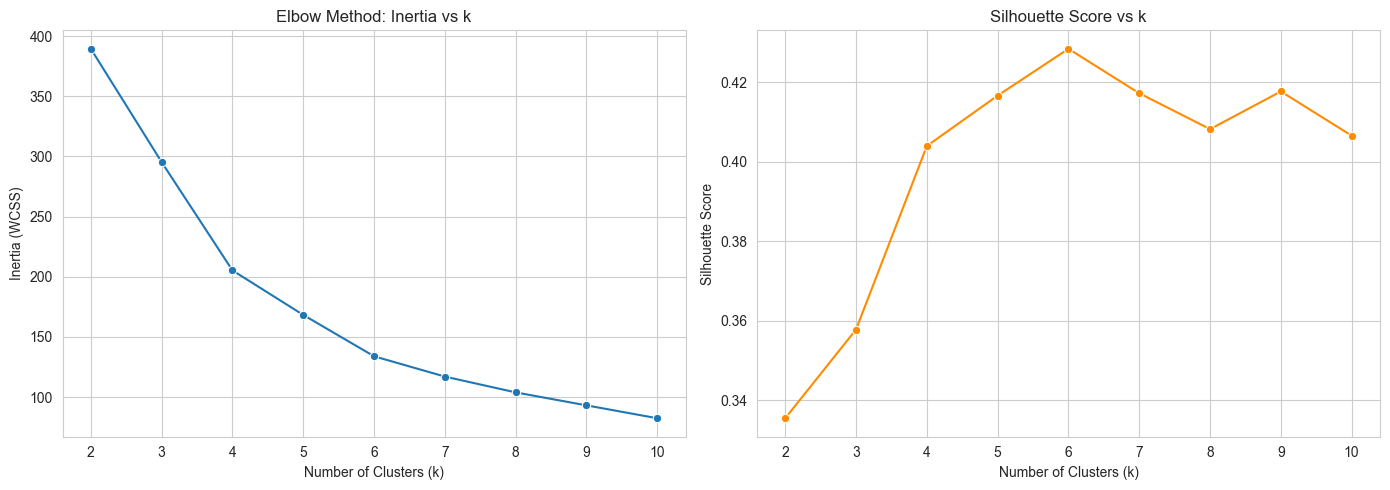

Best k by silhouette score: 6


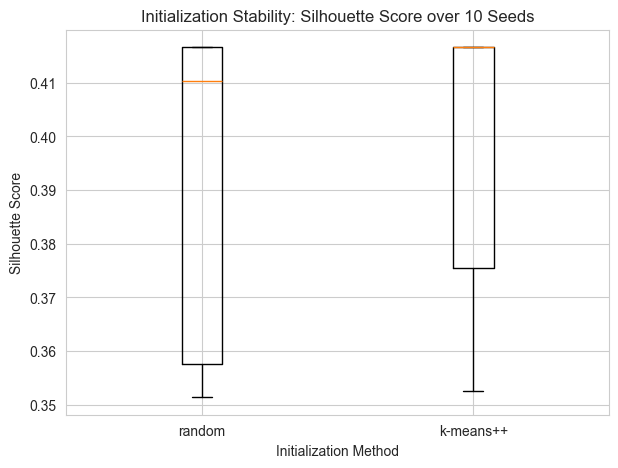

random       -> mean silhouette=0.3909, std=0.0292
k-means++    -> mean silhouette=0.3993, std=0.0266


In [18]:
# --- Experiment 1: vary k, track inertia (Elbow Method) and silhouette score ---
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=list(k_range), y=inertias, marker="o", ax=axes[0])
axes[0].set_title("Elbow Method: Inertia vs k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")

sns.lineplot(x=list(k_range), y=silhouettes, marker="o", color="darkorange", ax=axes[1])
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette score: {best_k}")

# --- Experiment 2: vary init method, repeated runs act as a simple cross-validation over init randomness ---
init_methods = ["random", "k-means++"]
results = {method: [] for method in init_methods}

for method in init_methods:
    for seed in range(10):
        km = KMeans(n_clusters=5, init=method, n_init=1, random_state=seed)
        labels_m = km.fit_predict(X_scaled)
        results[method].append(silhouette_score(X_scaled, labels_m))

plt.figure(figsize=(7, 5))
plt.boxplot([results["random"], results["k-means++"]], tick_labels=["random", "k-means++"])
plt.title("Initialization Stability: Silhouette Score over 10 Seeds")
plt.xlabel("Initialization Method")
plt.ylabel("Silhouette Score")
plt.show()

for method in init_methods:
    print(f"{method:12s} -> mean silhouette={np.mean(results[method]):.4f}, std={np.std(results[method]):.4f}")

## Part 5: Interview Corner

**Q: How do you choose the number of clusters `k` in K-Means, and why can't you just pick the `k` that minimizes inertia?**

Inertia (within-cluster sum of squares) decreases **monotonically** as `k` increases — taken to the extreme, `k = n_samples` drives inertia to zero (every point is its own cluster), which is a useless clustering. So `k` can never be chosen by minimizing inertia directly. Instead:

- **Elbow Method** — plot inertia vs. `k` and look for the point where the rate of decrease sharply flattens (the "elbow"); clusters added past that point yield diminishing returns.
- **Silhouette Score** — combines intra-cluster cohesion and inter-cluster separation into a single score; pick the `k` that maximizes it.
- **Domain knowledge** — in a business setting (like this mall dataset), `k` is also constrained by how many distinct customer segments the business can realistically design separate marketing strategies for.

A strong interview answer combines a quantitative signal (elbow/silhouette) **with** a sanity check against domain interpretability — relying on pure mathematical optimization without business context is a common pitfall interviewers specifically probe for.

## Key Takeaways

- K-Means partitions data into `k` clusters by alternating between assigning points to the nearest centroid and recomputing centroids as cluster means (Lloyd's algorithm), converging to a **local optimum**.
- **Feature scaling is mandatory** — K-Means relies on Euclidean distance, so unscaled features (e.g. income in thousands vs. a 1–100 score) would otherwise dominate the clustering unfairly.
- `k` is a hyperparameter, not learned from data — use the **Elbow Method** and **Silhouette Score** together, balanced against domain interpretability, to choose it.
- **Initialization matters**: k-means++ (scikit-learn's default) spreads out initial centroids and converges to better, more stable solutions than naive random initialization.
- K-Means assumes roughly **spherical, similarly-sized clusters** and is sensitive to outliers — for non-convex or highly imbalanced cluster shapes, consider **DBSCAN**, **Gaussian Mixture Models**, or **hierarchical clustering** instead.